# Predicting Employee Attrition and Identifying Flight Risk Factors

**Group Members:** Shania Siew (816039282), Terrence Murray (816038951), Tyler Baksh (816039328), Syam Manchikanti (816041877)

## Introduction

Employee attrition is expensive. When someone leaves unexpectedly, the company deals with disrupted operations, lost productivity, and recruitment costs that can run anywhere from 50% to 200% of that person's annual salary. Despite this, most organizations still handle turnover reactively, scrambling to fill roles after people have already walked out the door.

This project builds a workforce intelligence platform that flips that approach. We use machine learning classifiers and survival analysis to predict which employees are likely to leave and roughly when, giving organizations a 3 to 6 month window to step in. We also dig into the factors behind flight risk (overtime, tenure, job satisfaction, pay) and check whether our models treat employees fairly across protected attributes like gender, age, marital status, and education field.

We work primarily with the **IBM HR Analytics Employee Attrition & Performance** dataset, which contains detailed employee records covering tenure, salary, role, performance ratings, and attrition status. It's well suited for both classification and survival analysis. We supplement it with the **HR Analytics Job Change of Data Scientists** dataset for additional context on workforce mobility and career transitions.

Our deliverables include a predictive attrition model with flight risk tiers, feature importance analysis (Random Forest, LASSO, SHAP) to surface the main attrition drivers, fairness audits across demographic subgroups, an ROI calculator for estimating cost savings from targeted retention efforts, and an interactive dashboard showing survival curves, risk profiles, and department-level attrition trends.

### Domain Context: Flight Risk Indicators and Data Considerations

Workforce analytics research points to several behavioral and organizational signals tied to flight risk: declining productivity, lower motivation, more absences, reluctance to take on new projects, and pulling back from professional development (AIHR, 2024). Mondore (cited by SHRM) suggests that predictive attrition models should draw on demographic data (age, gender, marital status, education, tenure), performance reviews, engagement surveys, workload metrics, PTO and absenteeism records, and compensation data. He emphasizes including compensation so leadership can put a dollar figure on what's at stake if turnover isn't addressed.

**What the IBM dataset covers:**

| Recommended Data Category | Available Features |
|---|---|
| Demographics & tenure | `Age`, `Gender`, `MaritalStatus`, `Education`, `YearsAtCompany`, `DistanceFromHome` |
| Performance metrics | `PerformanceRating` |
| Engagement & satisfaction | `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance`, `JobInvolvement` |
| Workload proxies | `OverTime` |
| Compensation & career growth | `MonthlyIncome`, `PercentSalaryHike`, `StockOptionLevel`, `YearsSinceLastPromotion`, `JobLevel` |
| Career mobility | `NumCompaniesWorked`, `TotalWorkingYears`, `TrainingTimesLastYear`, `YearsInCurrentRole` |

**Limitations:** time-series engagement survey data, PTO/absenteeism records, exit survey responses, and granular productivity metrics. These gaps are a known limitation of working with this dataset.

*Sources: [AIHR — Flight Risk Employee](https://www.aihr.com/blog/flight-risk-employee/), [SHRM — How to Identify Company's Flight Risks](https://www.shrm.org/topics-tools/news/technology/how-to-identify-companys-flight-risks)*

## Part 1: Data Exploration and Cleaning

Before we build any models, we need to get familiar with our data. This section covers:

**Data Quality Checks**
- Load and inspect the dataset (schema, types, dimensions)
- Check for missing values and duplicates
- Drop constant and ID columns (`EmployeeCount`, `StandardHours`, `Over18`, `EmployeeNumber`)

**Exploratory Analysis**
- Summary statistics and distribution plots for numeric, ordinal, and categorical features
- Skewness analysis and log transforms for right-tailed features
- Outlier detection using the IQR method

**Preprocessing**
- Inspect the `Attrition` target variable for class imbalance
- Encode categorical variables (binary mapping + one-hot encoding)

### 1.1.1 Loading and Inspecting the Dataset

First, we download and load the IBM HR Analytics Employee Attrition & Performance dataset. Once it's loaded, we take a quick look at the shape, column names, and data types to get a sense of what we're working with.

In [1]:
import polars as pl
import requests
import os

# Data Directory
DATA_DIR = "data/raw"
FILE_NAME = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
os.makedirs(DATA_DIR, exist_ok=True)

# Download the dataset from source
url: str = "https://www.kaggle.com/api/v1/datasets/download/pavansubhasht/ibm-hr-analytics-attrition-dataset"

# Check if the dataset already exists
dataset_path = os.path.join(DATA_DIR, "ibm_hr_analytics_attrition_dataset.zip")
if os.path.exists(dataset_path):
    print("Dataset already exists. Skipping download.")
else:
    # Stream download the dataset
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(os.path.join(DATA_DIR, "ibm_hr_analytics_attrition_dataset.zip"), "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    else:    print(f"Failed to download dataset. Status code: {response.status_code}")

# Unzip the dataset
import zipfile
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)

Dataset already exists. Skipping download.


In [2]:
# Load the dataset using Polars
df = pl.read_csv(os.path.join(DATA_DIR, FILE_NAME))

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns\n")

# List all columns with their data types
for col in df.columns:
    print(f"  {col:30s} {str(df[col].dtype)}")

Dataset loaded: 1470 rows, 35 columns

  Age                            Int64
  Attrition                      String
  BusinessTravel                 String
  DailyRate                      Int64
  Department                     String
  DistanceFromHome               Int64
  Education                      Int64
  EducationField                 String
  EmployeeCount                  Int64
  EmployeeNumber                 Int64
  EnvironmentSatisfaction        Int64
  Gender                         String
  HourlyRate                     Int64
  JobInvolvement                 Int64
  JobLevel                       Int64
  JobRole                        String
  JobSatisfaction                Int64
  MaritalStatus                  String
  MonthlyIncome                  Int64
  MonthlyRate                    Int64
  NumCompaniesWorked             Int64
  Over18                         String
  OverTime                       String
  PercentSalaryHike              Int64
  PerformanceRat

### Ordinal Feature Mappings

Several numeric columns in the dataset represent ordinal categorical variables. The integer encodings correspond to the following labels:

| Column | 1 | 2 | 3 | 4 | 5 |
|--------|---|---|---|---|---|
| **Education** | Below College | College | Bachelor | Master | Doctor |
| **EnvironmentSatisfaction** | Low | Medium | High | Very High | — |
| **JobInvolvement** | Low | Medium | High | Very High | — |
| **JobSatisfaction** | Low | Medium | High | Very High | — |
| **PerformanceRating** | Low | Good | Excellent | Outstanding | — |
| **RelationshipSatisfaction** | Low | Medium | High | Very High | — |
| **WorkLifeBalance** | Bad | Good | Better | Best | — |

These fields are already numerically encoded in a meaningful ordinal order, so they can be used directly in modeling without further transformation.

### 1.1.3 Missing Value Analysis

We check every column for nulls. If any are found, we'll decide whether to impute or drop them.

In [3]:
# Count nulls per column
null_counts = df.null_count()
total_nulls = sum(null_counts.row(0))

if total_nulls == 0:
    print(f"No missing values found across all {len(df.columns)} columns.")
else:
    # Show only columns with nulls
    for col in df.columns:
        n = df[col].null_count()
        if n > 0:
            print(f"  {col}: {n} nulls ({n / len(df) * 100:.1f}%)")

No missing values found across all 35 columns.


### 1.1.4 Duplicate Detection

We check for duplicate rows and remove them if any exist.

In [4]:
# Check for and remove duplicate rows
n_before = len(df)
df = df.unique()
n_dupes = n_before - len(df)

if n_dupes == 0:
    print(f"No duplicate rows found ({n_before} rows).")
else:
    print(f"Removed {n_dupes} duplicate rows. {n_before} -> {len(df)} rows.")

No duplicate rows found (1470 rows).


### 1.1.2 Removing Irrelevant Features

Looking at the columns, `EmployeeNumber` is just a unique row ID, while `EmployeeCount`, `StandardHours`, and `Over18` are the same value for every row. None of these tell us anything useful about attrition, so we drop them.

In [5]:
drop_cols: list[str] = ["EmployeeCount", "EmployeeNumber", "StandardHours", "Over18"]

df = df.drop(drop_cols)

print(f"Dropped {len(drop_cols)} columns: {drop_cols}")
print(f"Remaining: {df.shape[0]} rows, {df.shape[1]} columns")

Dropped 4 columns: ['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18']
Remaining: 1470 rows, 31 columns


### 1.2.1 Summary Statistics

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# -- Feature groups --
# Ordinal: integer-coded but represent ranked categories (see mappings above)
ordinal_cols: list[str] = [
    "Education", "EnvironmentSatisfaction", "JobInvolvement", "JobLevel",
    "JobSatisfaction", "PerformanceRating", "RelationshipSatisfaction",
    "StockOptionLevel", "TrainingTimesLastYear", "WorkLifeBalance",
]

# Categorical: string-typed columns
categorical_cols: list[str] = [col for col in df.columns if df[col].dtype == pl.String]

# Numeric: continuous int/float columns, excluding ordinals
numeric_cols: list[str] = [
    col for col in df.columns
    if df[col].dtype in [pl.Int64, pl.Float64] and col not in ordinal_cols
]


# -- Reusable plotting helpers --
def plot_grid(cols, ncols, plot_fn, title, figsize_per_row=4):
    """Create a grid of subplots, calling plot_fn(ax, col) for each column."""
    nrows = -(-len(cols) // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * figsize_per_row))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols):
        plot_fn(axes[i], col)

    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


print(f"Numeric features ({len(numeric_cols)}):     {numeric_cols}")
print(f"Ordinal features ({len(ordinal_cols)}):     {ordinal_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Numeric features (13):     ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Ordinal features (10):     ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance']
Categorical features (8): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


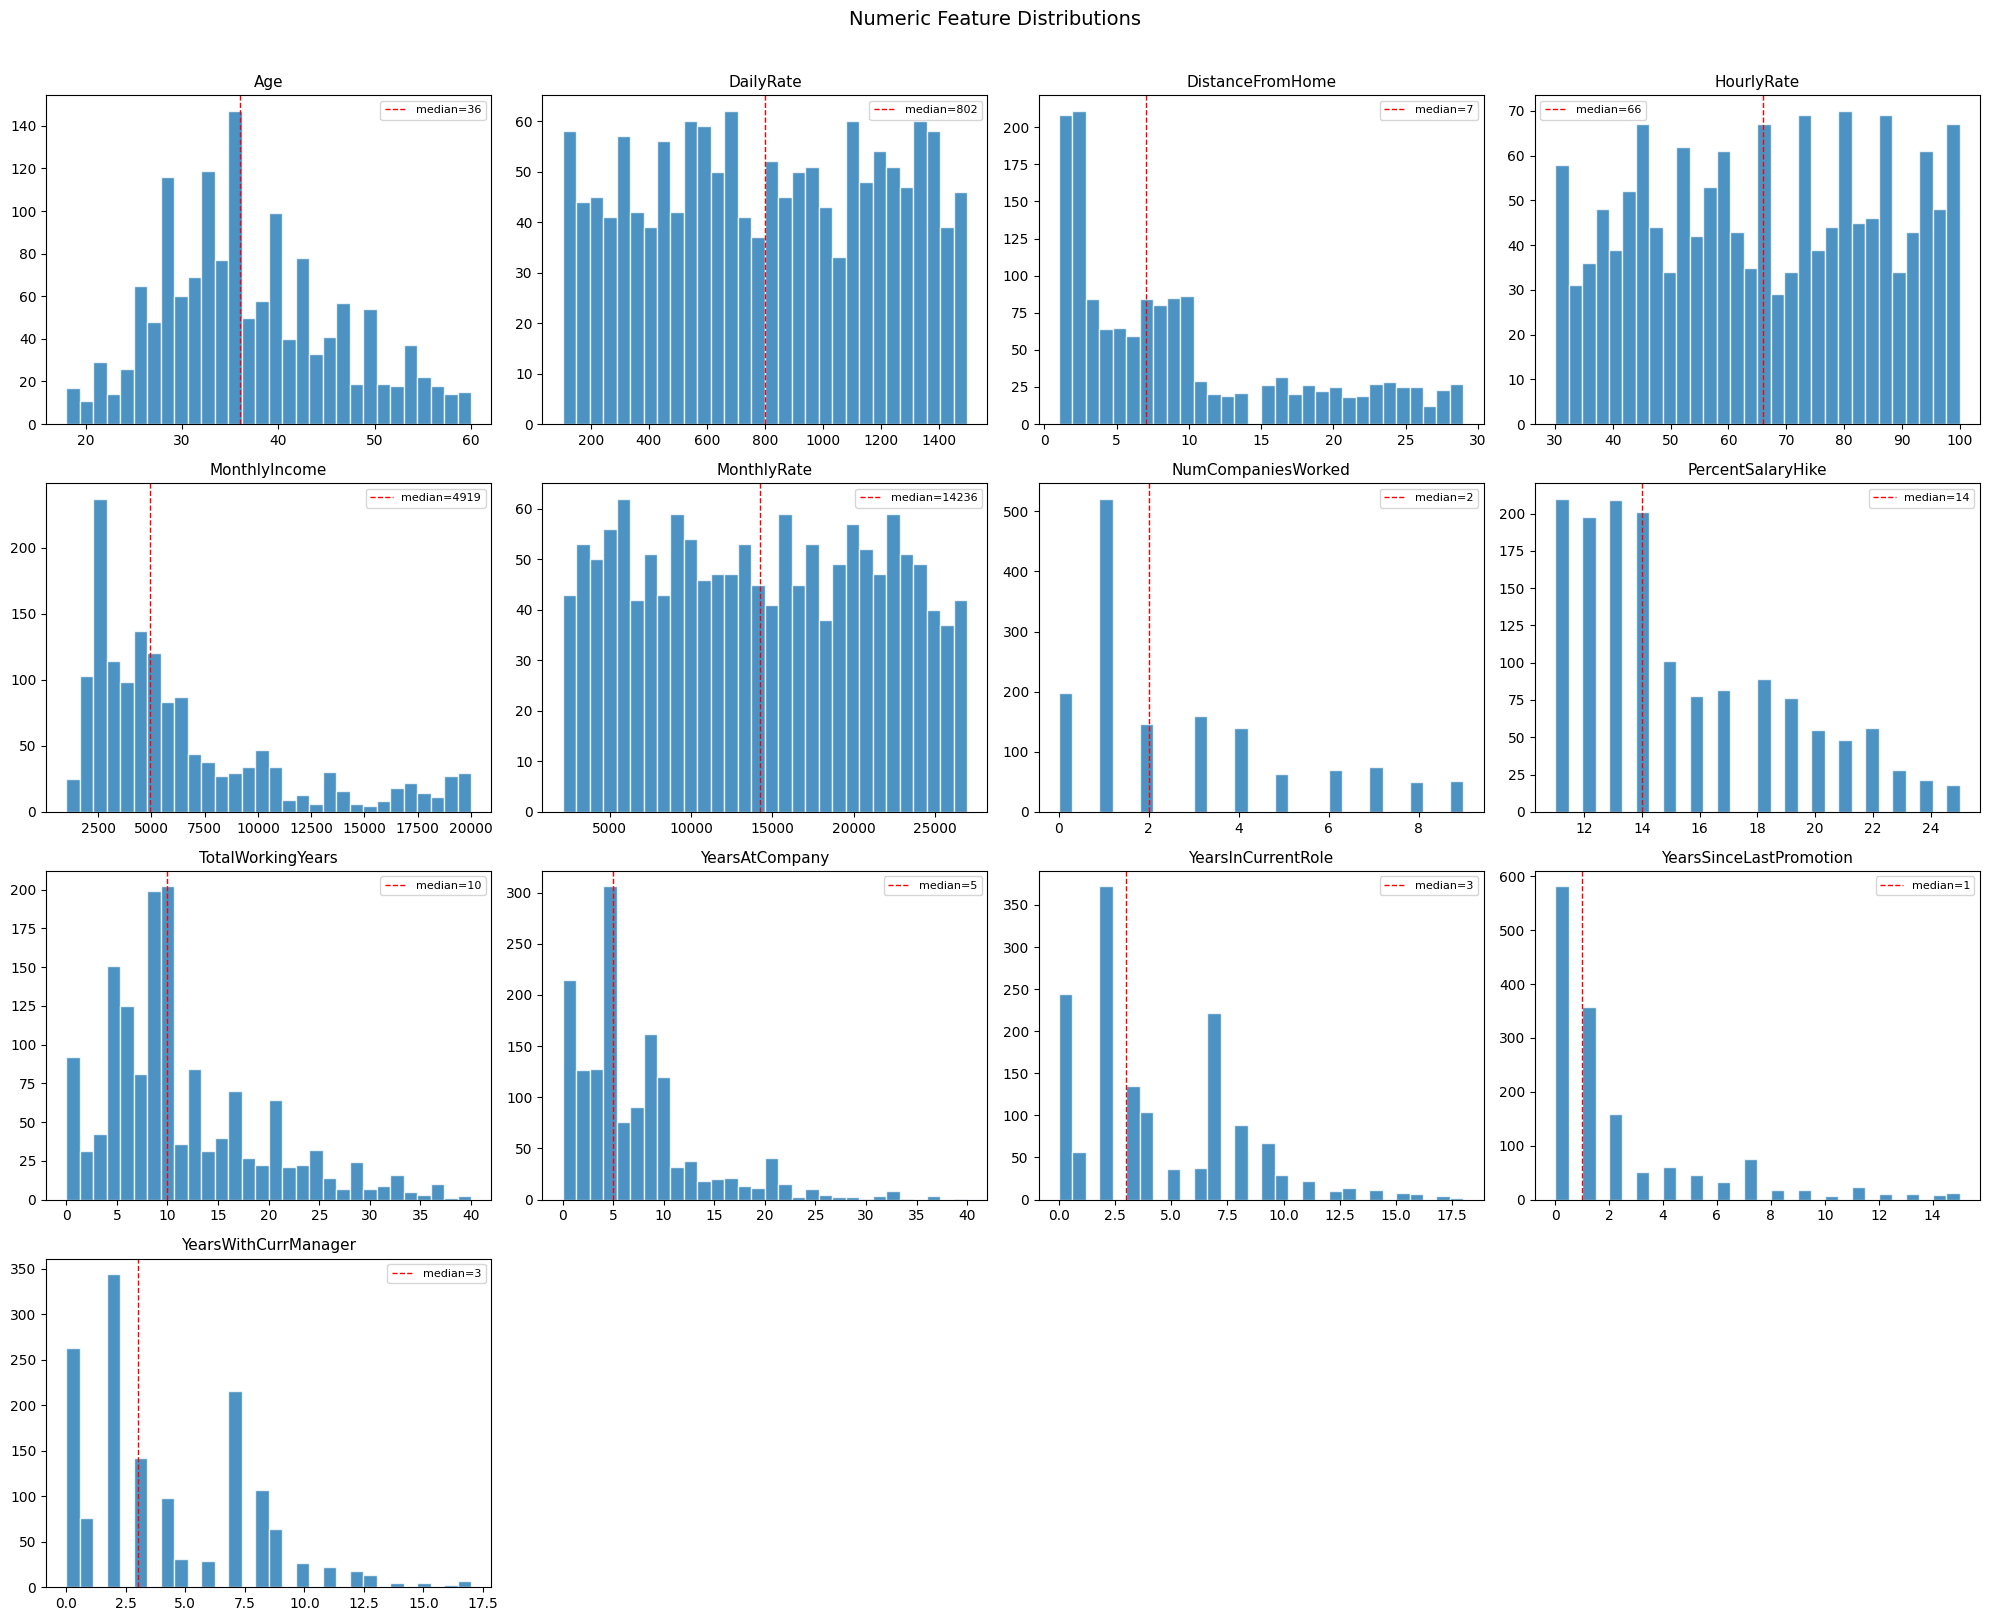

In [7]:
# Histogram + median line for each numeric feature
def plot_numeric_hist(ax, col):
    data = df.get_column(col).to_list()
    median = df.get_column(col).median()
    ax.hist(data, bins=30, edgecolor="white", alpha=0.8)
    ax.axvline(median, color="red", linestyle="--", linewidth=1, label=f"median={median:.0f}")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

plot_grid(numeric_cols, 4, plot_numeric_hist, "Numeric Feature Distributions")

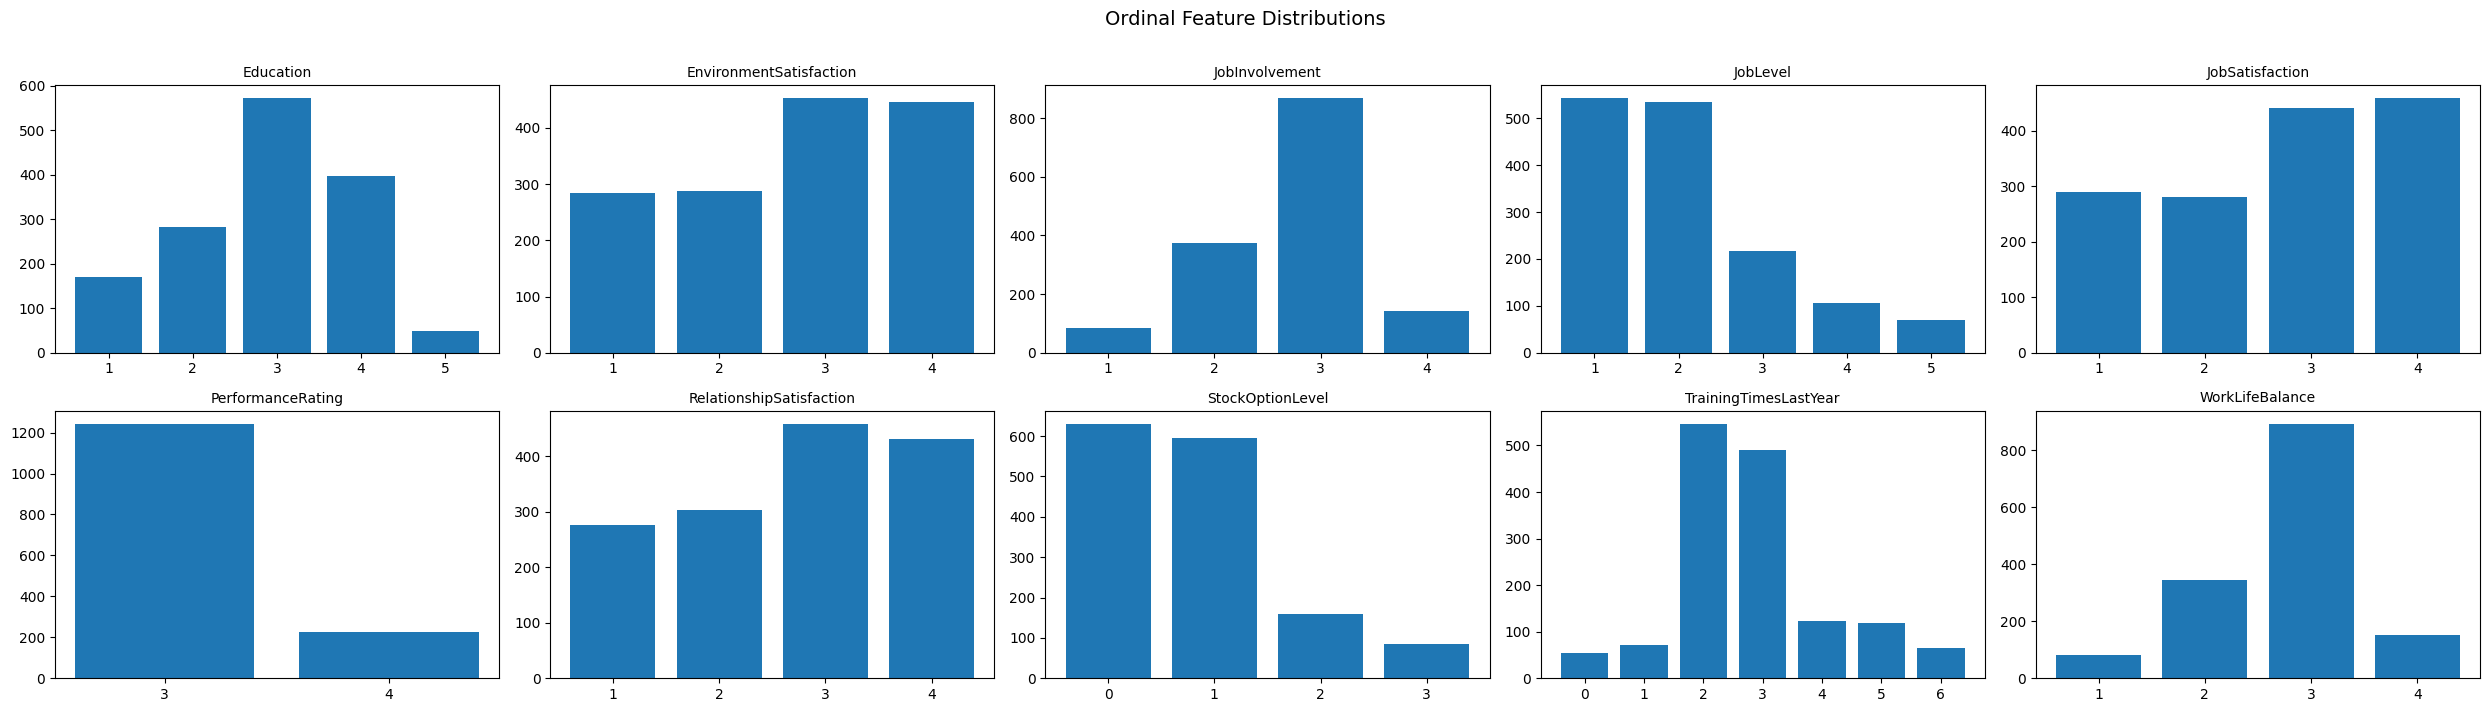

In [8]:
# Bar chart for each ordinal feature (sorted by category value)
def plot_ordinal_bar(ax, col):
    counts = df[col].value_counts().sort(col)
    ax.bar([str(v) for v in counts.get_column(col).to_list()], counts.get_column("count").to_list())
    ax.set_title(col, fontsize=10)

plot_grid(ordinal_cols, 5, plot_ordinal_bar, "Ordinal Feature Distributions", figsize_per_row=3.5)

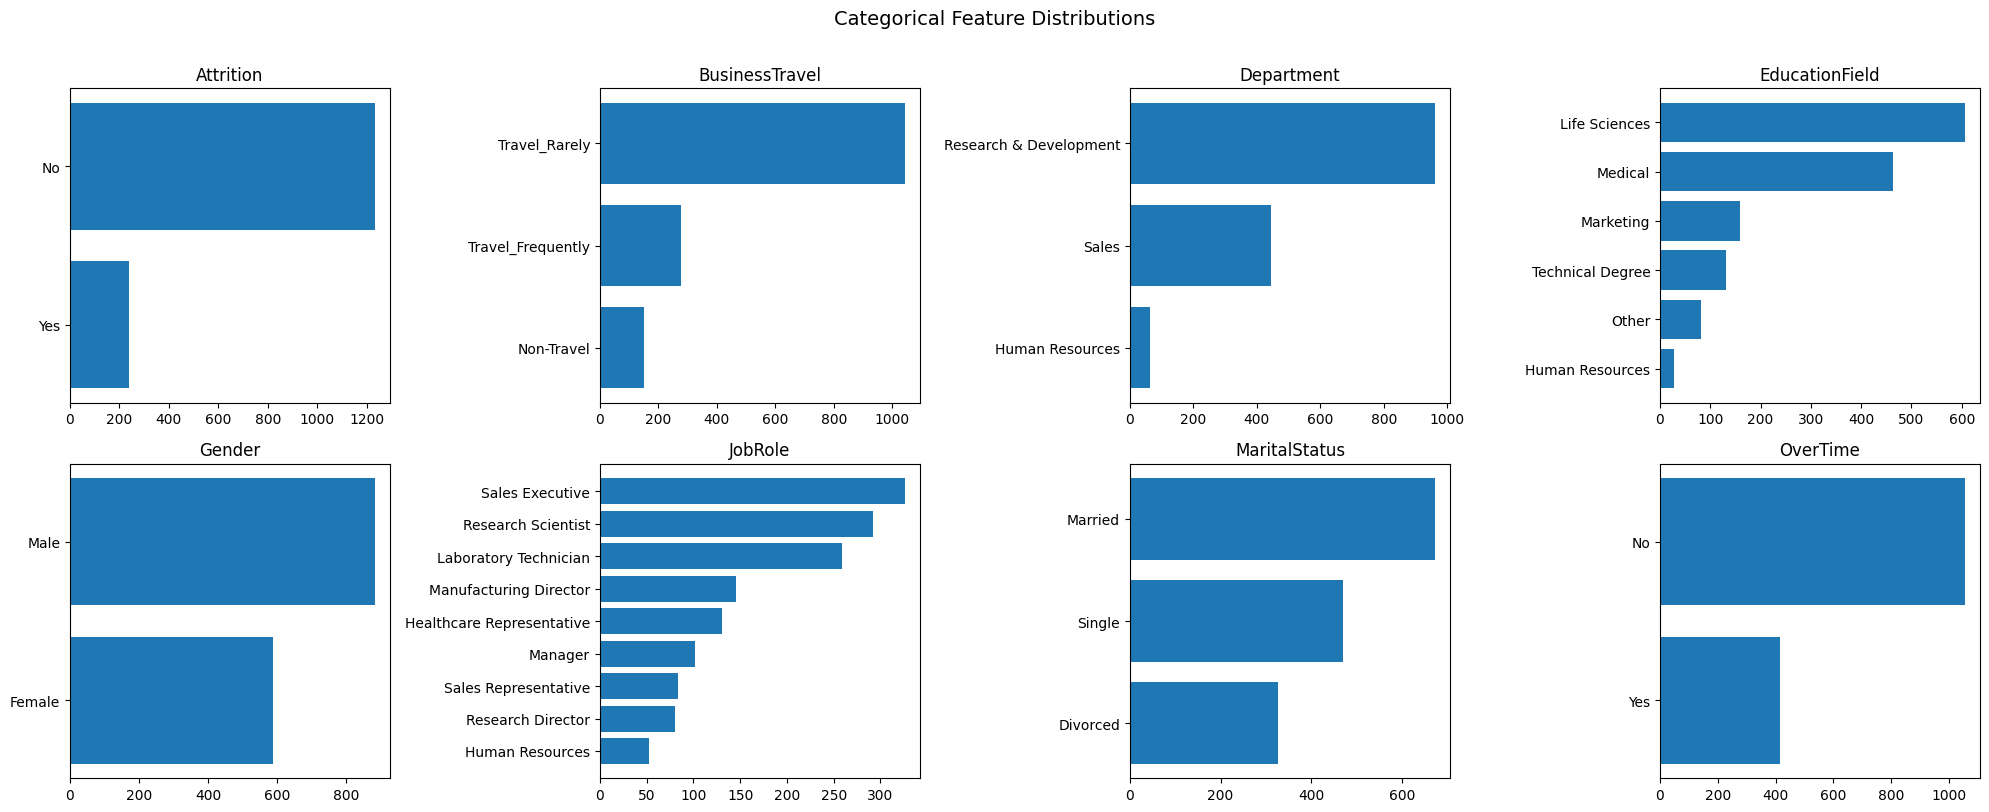

In [9]:
# Horizontal bar chart for each categorical feature (sorted by frequency)
def plot_categorical_bar(ax, col):
    counts = df[col].value_counts().sort("count", descending=True)
    ax.barh(counts.get_column(col).to_list(), counts.get_column("count").to_list())
    ax.set_title(col)
    ax.invert_yaxis()

plot_grid(categorical_cols, 4, plot_categorical_bar, "Categorical Feature Distributions")

### 1.2.2 Skewness and Outlier Assessment

A few of the numeric features are visibly right-skewed. Here we quantify the skewness and use box plots to spot outliers. As a rule of thumb, skewness beyond +/- 1 is considered significant. For outliers, we use the IQR method (points beyond 1.5x the interquartile range).

In [10]:
# Compute skewness using scipy and display sorted results
skew_records = [
    (col, round(stats.skew(df.get_column(col).to_list()), 2))
    for col in numeric_cols
]
skew_df = pl.DataFrame({"Feature": [r[0] for r in skew_records], "Skewness": [r[1] for r in skew_records]})
skew_df = skew_df.sort("Skewness", descending=True)

print("Skewness of numeric features (|skew| > 1 is notable):\n")
for feat, skew in skew_df.iter_rows():
    flag = " !!" if abs(skew) > 1 else ""
    print(f"  {feat:30s} {skew:>6.2f}{flag}")

Skewness of numeric features (|skew| > 1 is notable):

  YearsSinceLastPromotion          1.98 !!
  YearsAtCompany                   1.76 !!
  MonthlyIncome                    1.37 !!
  TotalWorkingYears                1.12 !!
  NumCompaniesWorked               1.03 !!
  DistanceFromHome                 0.96
  YearsInCurrentRole               0.92
  YearsWithCurrManager             0.83
  PercentSalaryHike                0.82
  Age                              0.41
  MonthlyRate                      0.02
  DailyRate                       -0.00
  HourlyRate                      -0.03


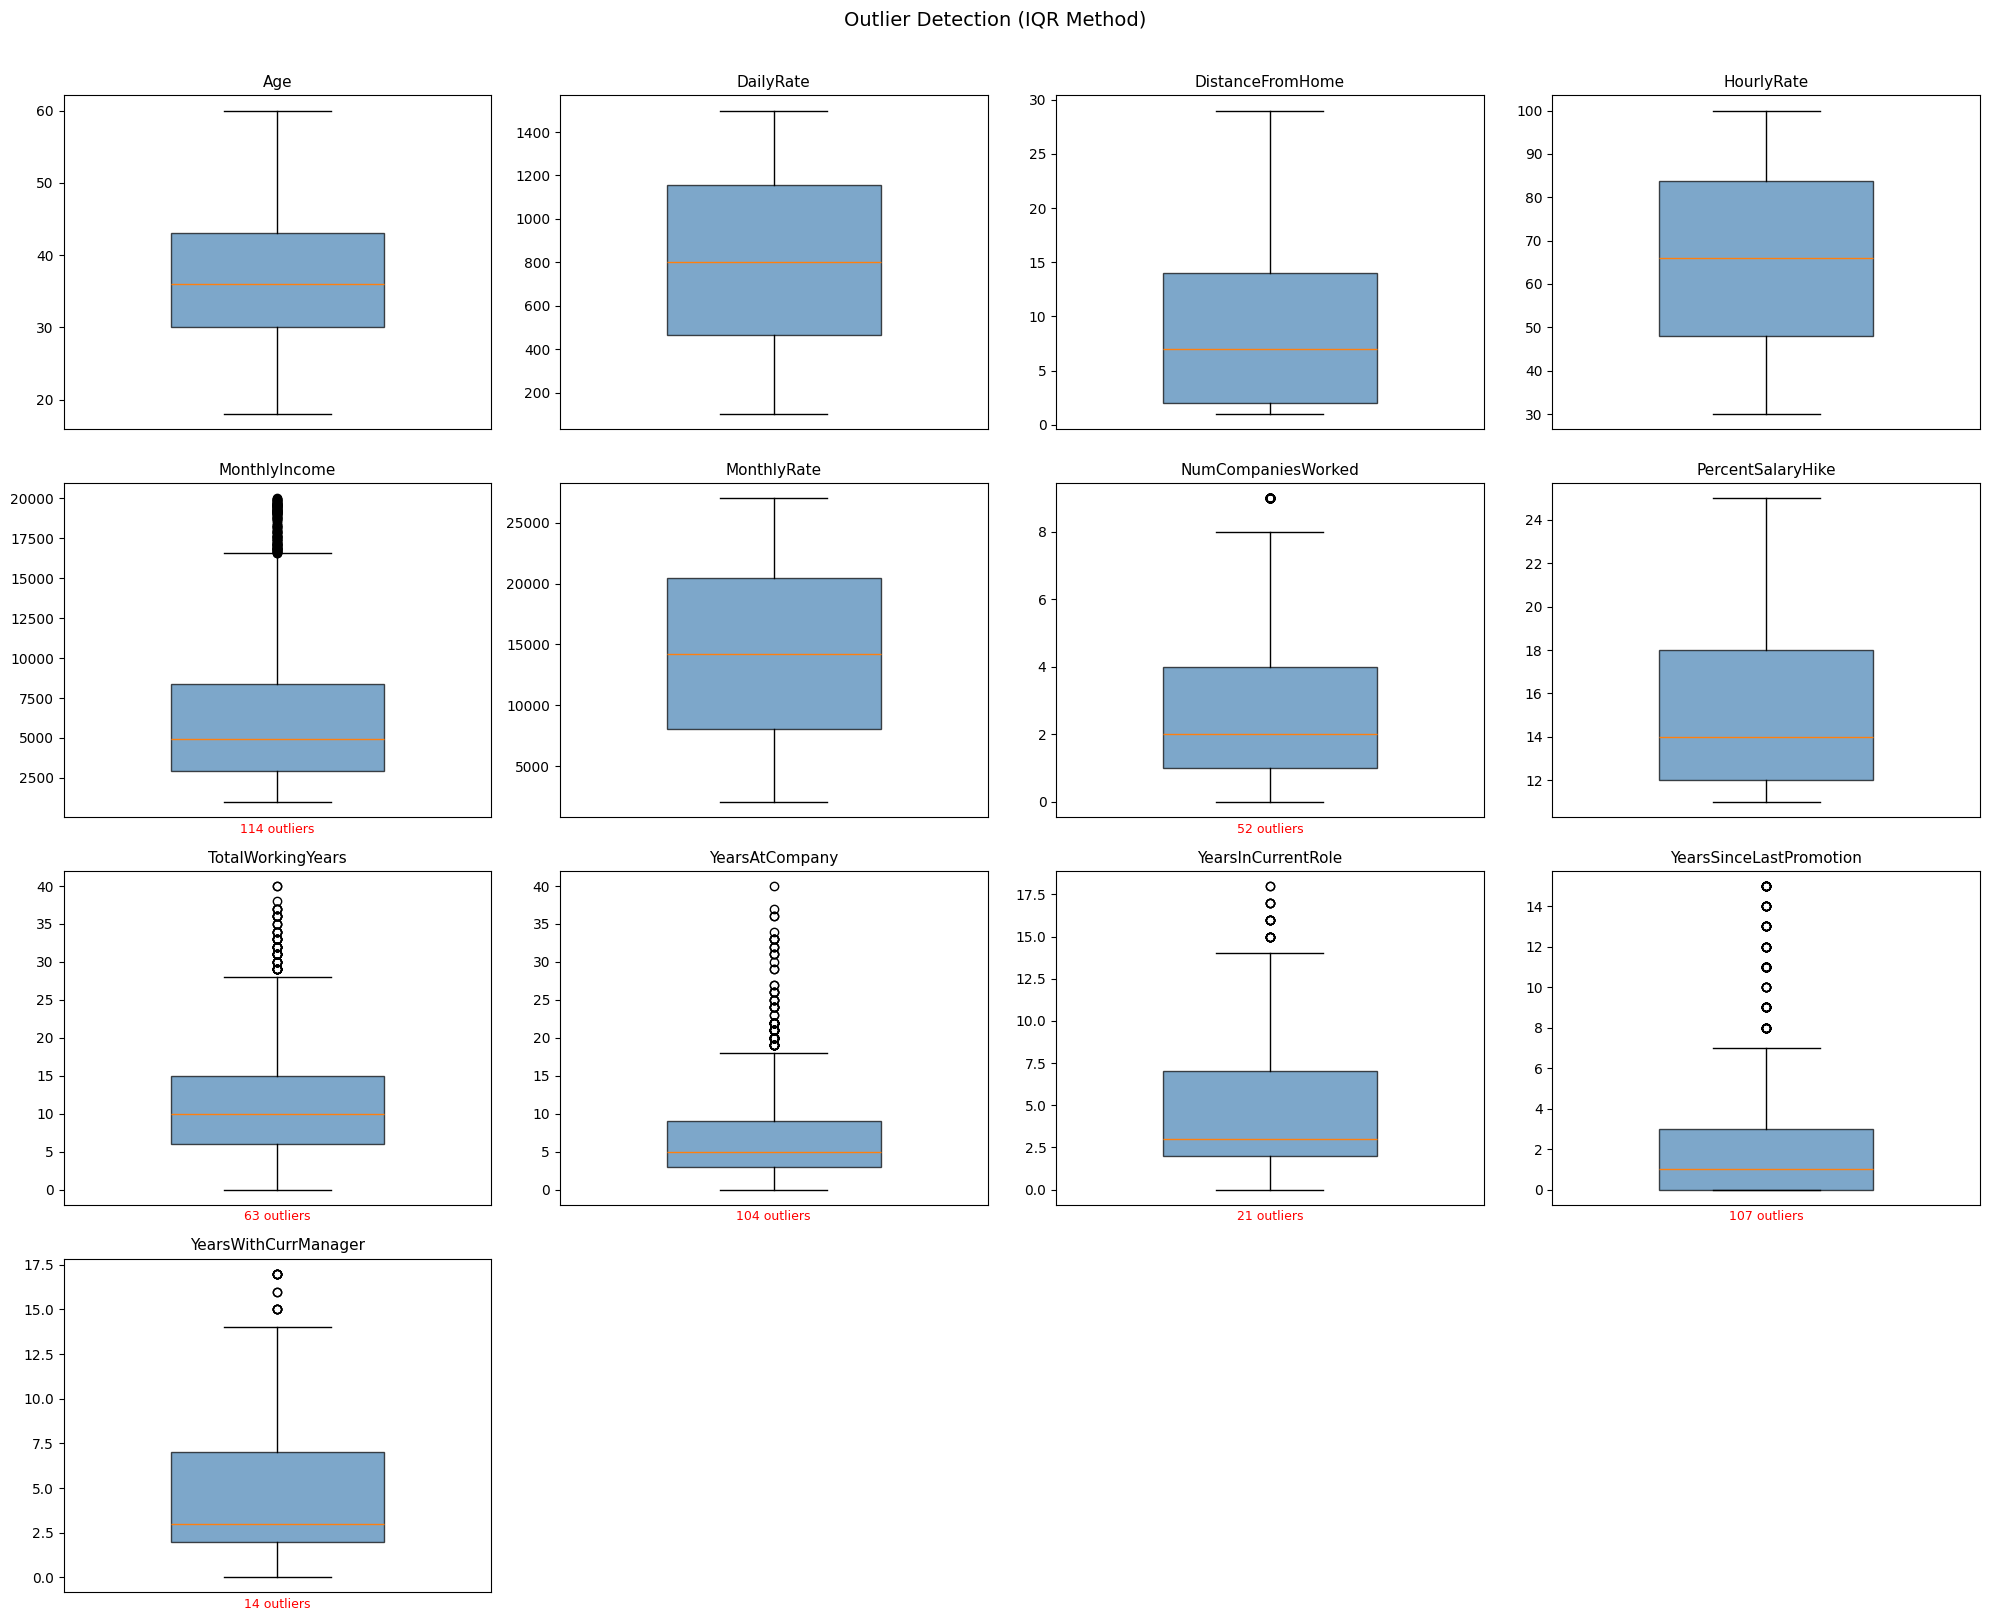

In [11]:
# Box plot + outlier count for each numeric feature
def plot_boxplot(ax, col):
    data = df.get_column(col).to_list()
    bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.5)
    bp["boxes"][0].set(facecolor="steelblue", alpha=0.7)
    ax.set_title(col, fontsize=11)
    ax.set_xticks([])

    # Count IQR outliers
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    n_outliers = sum(1 for v in data if v < q1 - 1.5 * iqr or v > q3 + 1.5 * iqr)
    if n_outliers > 0:
        ax.set_xlabel(f"{n_outliers} outliers", fontsize=9, color="red")

plot_grid(numeric_cols, 4, plot_boxplot, "Outlier Detection (IQR Method)")

### 1.2.3 Log Transform for Skewed Features

For features with skewness above 1, we apply a `log1p` transform (log(1 + x)) to pull in the right tail. We use `log1p` instead of plain `log` because some features contain zeros. This mainly benefits LASSO and other linear models; tree-based models like Random Forest won't be affected either way.

Applying log1p to 5 skewed features: ['YearsSinceLastPromotion', 'YearsAtCompany', 'MonthlyIncome', 'TotalWorkingYears', 'NumCompaniesWorked']

Added columns: ['YearsSinceLastPromotion_log', 'YearsAtCompany_log', 'MonthlyIncome_log', 'TotalWorkingYears_log', 'NumCompaniesWorked_log']
DataFrame shape: 1470 rows, 36 columns


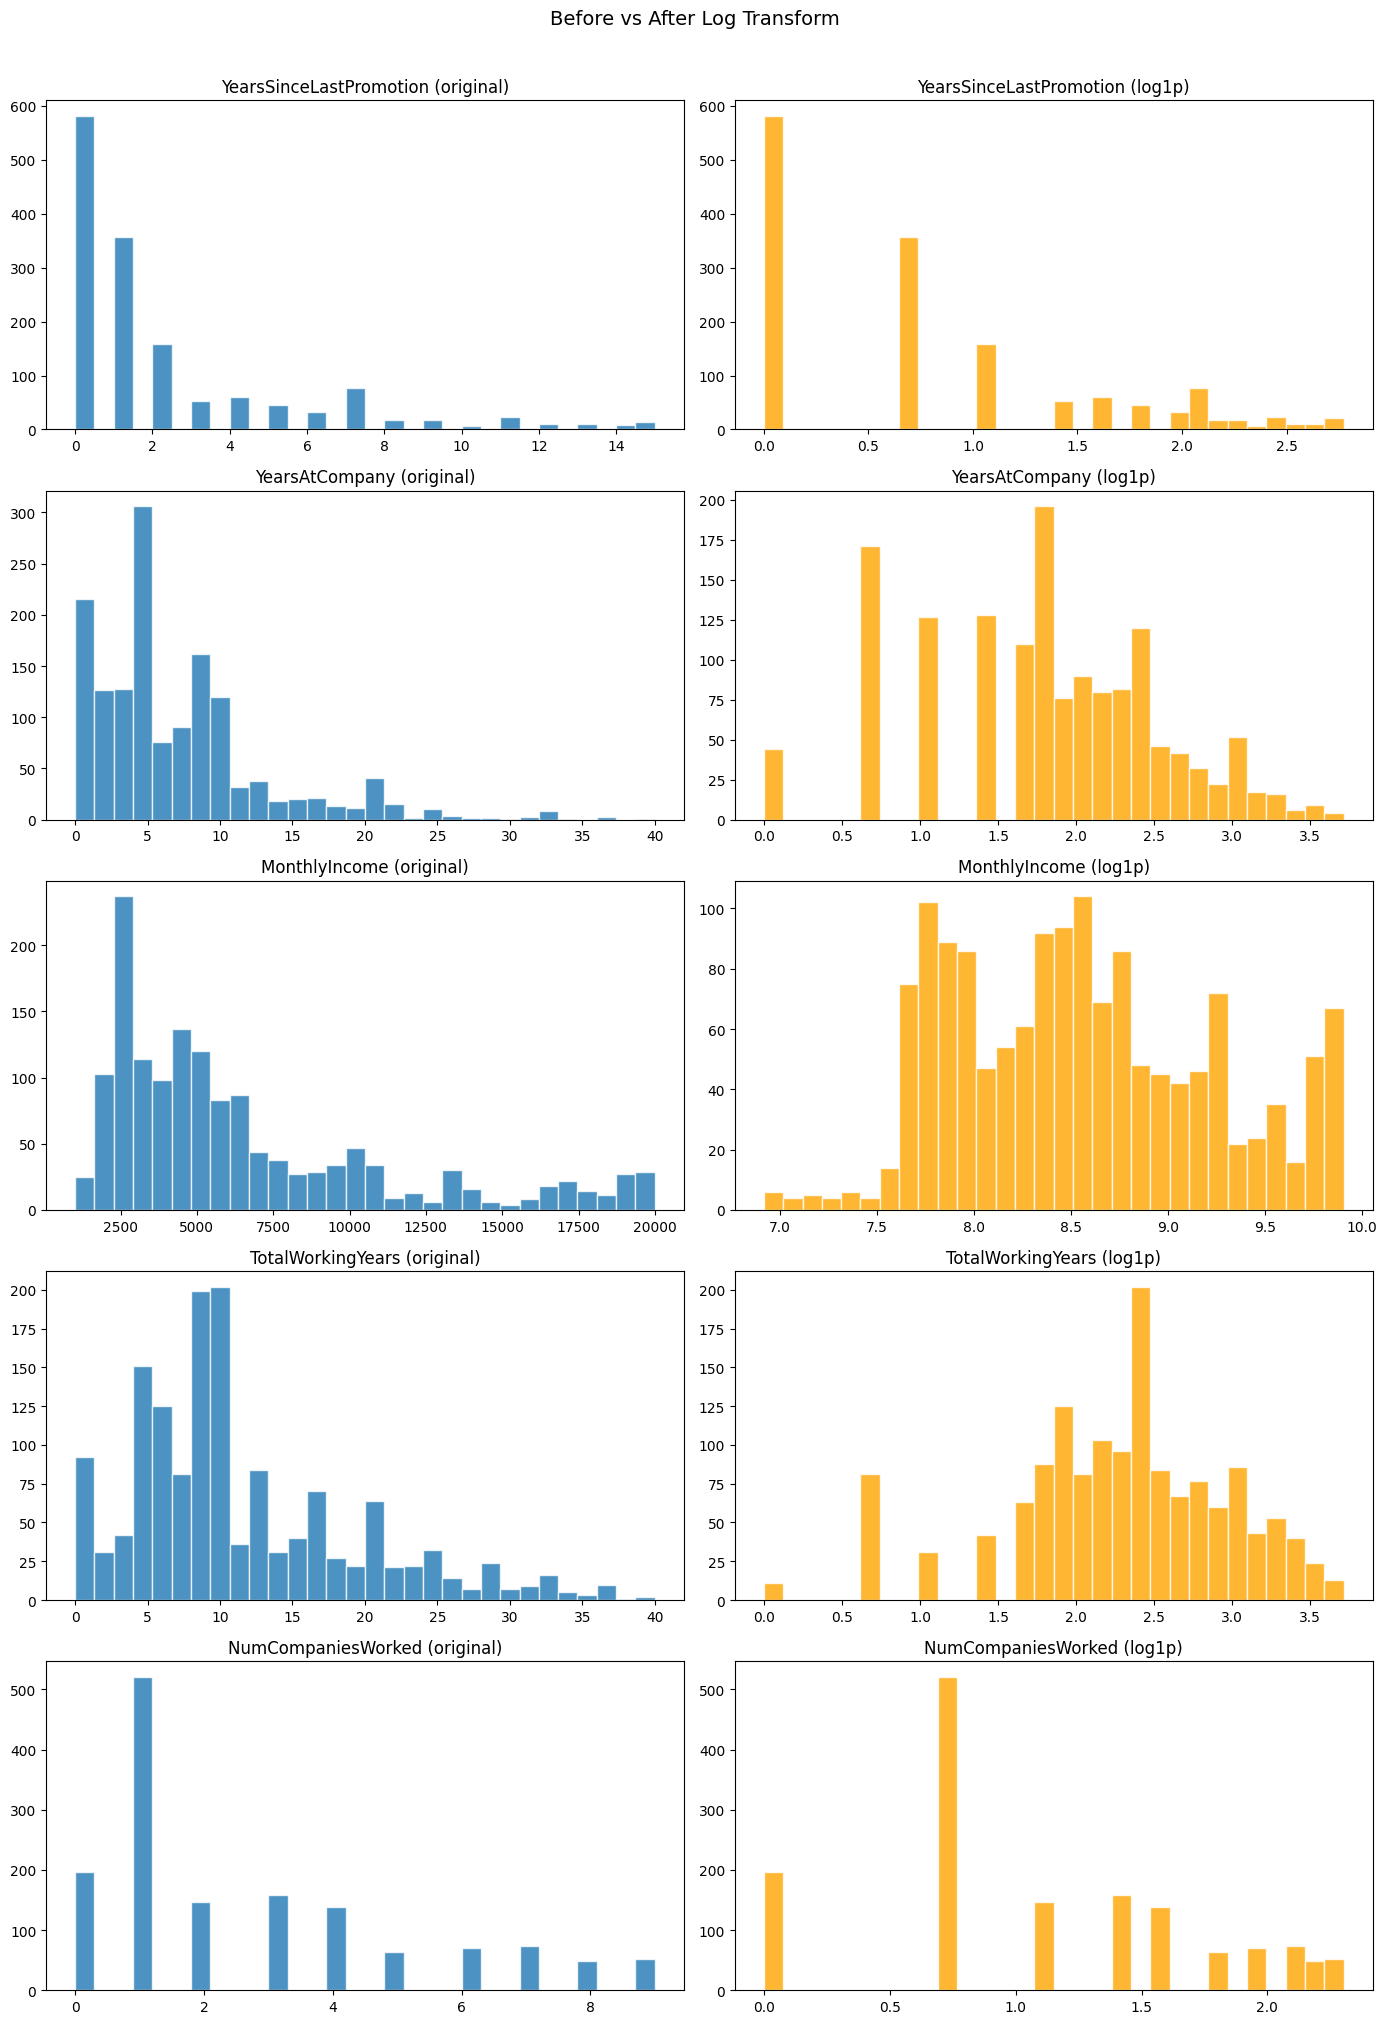

In [12]:
# Apply log1p to features with |skewness| > 1
skewed_cols = [feat for feat, skew in skew_df.iter_rows() if abs(skew) > 1]
print(f"Applying log1p to {len(skewed_cols)} skewed features: {skewed_cols}\n")

for col in skewed_cols:
    df = df.with_columns(pl.col(col).cast(pl.Float64).log1p().alias(f"{col}_log"))

print(f"Added columns: {[f'{c}_log' for c in skewed_cols]}")
print(f"DataFrame shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Side-by-side comparison: original vs transformed
fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(14, 4 * len(skewed_cols)))

for i, col in enumerate(skewed_cols):
    axes[i][0].hist(df.get_column(col).to_list(), bins=30, edgecolor="white", alpha=0.8)
    axes[i][0].set_title(f"{col} (original)")

    axes[i][1].hist(df.get_column(f"{col}_log").to_list(), bins=30, edgecolor="white", alpha=0.8, color="orange")
    axes[i][1].set_title(f"{col} (log1p)")

fig.suptitle("Before vs After Log Transform", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.3.1 Target Variable Inspection

We look at the distribution of `Attrition` to understand how imbalanced our classes are. This matters because if one class heavily outweighs the other, our models could just predict the majority class and still look accurate on paper.

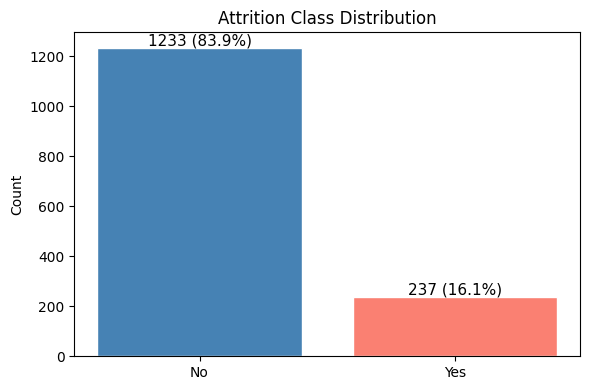

Imbalance ratio: 5.2 : 1


In [13]:
# Attrition class distribution
counts = df["Attrition"].value_counts().sort("Attrition")
total = len(df)

fig, ax = plt.subplots(figsize=(6, 4))
labels = counts.get_column("Attrition").to_list()
values = counts.get_column("count").to_list()
bars = ax.bar(labels, values, color=["steelblue", "salmon"], edgecolor="white")

# Add count and percentage labels on each bar
for bar, val in zip(bars, values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{val} ({pct:.1f}%)", ha="center", fontsize=11)

ax.set_title("Attrition Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Print imbalance ratio
majority, minority = max(values), min(values)
print(f"Imbalance ratio: {majority / minority:.1f} : 1")

### 1.3.2 Encoding Categorical Variables

We convert string columns into numeric form so they can be fed into our models. Binary columns (`Attrition`, `OverTime`, `Gender`) get mapped to 0/1, while multi-class columns (`BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus`) are one-hot encoded.

In [14]:
# Binary encoding for two-value columns
binary_maps = {
    "Attrition": {"No": 0, "Yes": 1},
    "OverTime":  {"No": 0, "Yes": 1},
    "Gender":    {"Female": 0, "Male": 1},
}

for col, mapping in binary_maps.items():
    df = df.with_columns(pl.col(col).replace(mapping).cast(pl.Int64).alias(col))

print(f"Binary encoded: {list(binary_maps.keys())}")

# One-hot encoding for multi-class columns
multi_class_cols = ["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus"]
df = df.to_dummies(columns=multi_class_cols)

new_cols = [c for c in df.columns if any(c.startswith(f"{mc}_") for mc in multi_class_cols)]
print(f"One-hot encoded: {multi_class_cols} -> {len(new_cols)} new columns")
print(f"\nFinal shape: {df.shape[0]} rows, {df.shape[1]} columns")

Binary encoded: ['Attrition', 'OverTime', 'Gender']
One-hot encoded: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'] -> 24 new columns

Final shape: 1470 rows, 55 columns


### Part 1 Findings

**Data Quality**
- The dataset is clean out of the box: no missing values and no duplicate rows across all 1,470 records. Four columns (`EmployeeCount`, `StandardHours`, `Over18`, `EmployeeNumber`) were dropped because they were either constant or just row IDs, leaving 31 meaningful features.

**Distributions**
- Most numeric features are right-skewed. Five in particular (`YearsSinceLastPromotion`, `YearsAtCompany`, `MonthlyIncome`, `TotalWorkingYears`, `NumCompaniesWorked`) had skewness above 1.0, so we created `log1p` versions of these for use with linear models like LASSO.
- `DailyRate`, `HourlyRate`, and `MonthlyRate` are roughly uniformly distributed, which is unusual for salary-related fields.
- Ordinal satisfaction features (`JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`) are fairly evenly spread across their four levels, meaning there's no dominant sentiment skewing the data.

**Outliers**
- Several tenure and income features have IQR outliers on the upper end. These represent senior, long-tenured employees rather than data errors, so we kept them in the dataset.

**Class Imbalance**
- Attrition is heavily imbalanced at roughly 5:1 (83.9% No vs 16.1% Yes). This will need to be addressed during modeling, either through oversampling to prevent the models from simply predicting "No" for everyone.

**After Encoding**
- Binary mapping was applied to `Attrition`, `OverTime`, and `Gender`. One-hot encoding expanded `BusinessTravel`, `Department`, `EducationField`, `JobRole`, and `MaritalStatus` into 24 dummy columns. The final dataset has 1,470 rows and 55 columns ready for modeling.

## Part 2: Feature Engineering

Before we build any models, we must engineer the necessary features. This section includes:

- Tenure calculations
- Satisfaction composites
- Identification of censored vs. uncensored observations

### 2.1 Tenure Calculations

The dataset has several raw tenure columns (`YearsAtCompany`, `TotalWorkingYears`, `YearsInCurrentRole`, `YearsWithCurrManager`, `YearsSinceLastPromotion`). This section will extract _ratios and rates_ that are more informative than the raw values alone.

In [15]:
# + 1 in denominators to avoid division by zero for new hires
df = df.with_columns([
    # Fraction of total career spent at this company
    (pl.col('YearsAtCompany') / (pl.col('TotalWorkingYears') + 1)).alias('TenureCompanyRatio'),
    
    # Fraction of time at company spent in current role
    (pl.col('YearsInCurrentRole') / (pl.col('YearsAtCompany') + 1)).alias('TenureRoleRatio'),

    # Fraction of time at company under current manager
    (pl.col('YearsWithCurrManager') / (pl.col('YearsAtCompany') + 1)).alias('TenureManagerRatio'),

    #Average tenure per company (job-hopping signal)
    (pl.col('TotalWorkingYears') / (pl.col('NumCompaniesWorked') + 1)).alias('AvgTenurePerCompany'),

    # Promotion lag: years stagnant relative to total tenure
    (pl.col('YearsSinceLastPromotion') / (pl.col('YearsAtCompany') + 1)).alias('PromotionLagRatio'),

    #Career stage bins
    pl.col('TotalWorkingYears')
        .cut(breaks=[2, 5, 10, 20],
             labels=['entry', 'early', 'mid', 'senior', 'veteran'])
        .alias('CareerStage')
])

df.select(['TenureCompanyRatio', 'TenureRoleRatio', 'TenureManagerRatio', 'AvgTenurePerCompany', 'PromotionLagRatio', 'CareerStage']).head()

TenureCompanyRatio,TenureRoleRatio,TenureManagerRatio,AvgTenurePerCompany,PromotionLagRatio,CareerStage
f64,f64,f64,f64,f64,cat
0.947368,0.368421,0.894737,9.0,0.631579,"""senior"""
0.888889,0.777778,0.777778,4.0,0.555556,"""mid"""
0.166667,0.25,0.5,5.666667,0.0,"""senior"""
0.888889,0.777778,0.666667,4.0,0.111111,"""mid"""
0.9,0.7,0.8,4.5,0.0,"""mid"""


#### Key Points

- When `TenureCompanyRatio` is near 1.0, this indicates that the employee's entire career is at this company
- When `TenureRoleRatio` is near 0, this indicates that the employeed recently moved roles
- When `AvgTenurePerCompany` is low, this indicates that the employee is a job-hopper
- When `PromotionLagRatio` is high, this indicates that the employee's career may be stagnant

### 2.2 Satisfaction Composites

The dataset has 5 engagement and satisfaction columns, all on scales of 1 to 4: `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance` and `JobInvolvement`. Composities reduce dimensionality and capture latent "overall engagement".

In [16]:
SAT_COLS = [
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance',
    'JobInvolvement',
]

df = df.with_columns([
    # Simple mean (equal weight) — overall engagement score
    pl.concat_list([pl.col(c) for c in SAT_COLS])
        .list.mean()
        .alias('SatisfactionMean'),

    # Minimum — captures the "weakest link" dimension
    pl.concat_list([pl.col(c) for c in SAT_COLS])
        .list.min()
        .alias('SatisfactionMin'),

    # Standard deviation — measures inconsistency across dimensions
    # High variance = dissatisfied in some areas but not others
    pl.concat_list([pl.col(c).cast(pl.Float64) for c in SAT_COLS])
        .map_elements(lambda x: x.to_numpy().std(), return_dtype=pl.Float64)
        .alias('SatisfactionStd'),

    # Binary "at-risk" flag: mean below 2.5 (below midpoint of 1-4 scale)
    (pl.concat_list([pl.col(c) for c in SAT_COLS])
        .list.mean() < 2.5)
        .cast(pl.Int8)
        .alias('LowSatisfactionFlag'),

    # Work-life + job satisfaction sub-composite (most attrition-linked)
    ((pl.col('WorkLifeBalance') + pl.col('JobSatisfaction')) / 2)
        .alias('WLBJobComposite'),
])

df.select(['SatisfactionMean', 'SatisfactionMin', 'SatisfactionStd', 'LowSatisfactionFlag', 'WLBJobComposite']).head()

SatisfactionMean,SatisfactionMin,SatisfactionStd,LowSatisfactionFlag,WLBJobComposite
f64,i64,f64,i8,f64
2.6,1,1.019804,0,1.5
3.2,3,0.4,0,3.0
1.8,1,0.748331,1,1.5
3.2,2,0.748331,0,2.5
2.4,2,0.489898,1,2.0


### Key Points

- High `SatisfactionMean` = Broadly engaged, Low `SatisfactionMean` = Broadly Disengaged
- High `SatisfactionMin` = No critical pain point, Low `SatisfactionMin` = At least one severe issue
- High `SatisfactionStd` = Uneven experience, Low `SatisfactionStd` = Consistently good or bad
- When `LowSatisfactionFlag == True`, satisfaction is low

### 2.3 Identifying Censored vs. Uncensored Observations

An uncensored observation is one where the employee left during the observation window (`Attrition == 1`) while a censored observation is one where the employee was _still employed_ when the data was collected (`Attrition == 0`). For censored observations, we don't know if/when employees will leave. 

All `Attrition == 0`employees are **right-censored**: they haven't had the event yet, but may in the future. For survival analysis, we must encode this explicitly.

In [17]:
df = df.with_columns([
    # Event indicator: 1 = uncensored (attrition observed), 0 = censored
    pl.col('Attrition').alias('EventObserved'),  # already 0/1 from encoding

    # Survival time = duration employee was observed
    # YearsAtCompany is the best proxy here (no hire/exit dates in this dataset)
    pl.col('YearsAtCompany').alias('SurvivalTime'),

    # Explicit censoring flag for clarity (inverse of event)
    (pl.col('Attrition') == 0).cast(pl.Int8).alias('IsCensored'),
])

# Summary
n_events   = df["EventObserved"].sum()
n_censored = df["IsCensored"].sum()
print(f"Uncensored (left): {n_events}  ({n_events/len(df)*100:.1f}%)")
print(f"Censored (stayed): {n_censored} ({n_censored/len(df)*100:.1f}%)")

Uncensored (left): 237  (16.1%)
Censored (stayed): 1233 (83.9%)


### 2.4 Ordinal Encoding
There is one categorical engineered column: `CareerStage`. Ordinal encoding is used for `CareerStage` instead of one-hot encoding because the categories have a clear natural order: `entry < early < mid < senior < veteran` This means the values carry rank/experience progression, not just separate labels.

In [18]:
# Ordinal encode CareerStage using a manual map to preserve the natural career progression order
CareerStageMap = {'entry': 0, 'early': 1, 'mid': 2, 'senior': 3, 'veteran': 4}
df = df.with_columns(
    pl.col('CareerStage').cast(pl.String).replace(CareerStageMap).cast(pl.Int64)
)

## Part 3: Classification

In this section, we apply different machine learning models to predict employee attrition.  
Because the dataset is imbalanced (many more "no attrition" cases than "attrition"), we use techniques like **class weighting** and **SMOTE** to ensure fair treatment of minority cases.  

We evaluate four models:
- Logistic Regression with class weights  
- LASSO Logistic Regression (regularized) with class weights  
- Random Forest with class weights  
- Random Forest with SMOTE oversampling  

Performance is assessed using accuracy, precision, recall, F1-score, AUROC, and confusion matrices.  
Macro averages are reported to give equal importance to both classes, ensuring minority attrition cases are not overshadowed by the majority class.Nb. More models to be added soon


### 3.1 Train-Test Split

Splits the dataset into training and testing sets (80/20) while preserving class proportions.

In [19]:
# Train-test split
from sklearn.model_selection import train_test_split
import pandas as pd

# Drop target + leakage columns
leakage_cols = ["EventObserved", "SurvivalTime", "IsCensored"]
X = pd.DataFrame(
    df.drop(leakage_cols + ["Attrition"]).to_numpy(),
    columns=[c for c in df.columns if c not in leakage_cols + ["Attrition"]]
)
y = pd.Series(df["Attrition"].to_numpy(), name="Attrition")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")


Training set: 1176 samples, 65 features


#### 3.2 SMOTE Oversampling

Balances the training data by generating synthetic minority samples to address class imbalance


In [20]:
# SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Original training set: {len(X_train)} samples, {y_train.sum()} positive")
print(f"SMOTE training set: {len(X_train_sm)} samples, {y_train_sm.sum()} positive")


Original training set: 1176 samples, 190 positive
SMOTE training set: 1972 samples, 986 positive


### 3.3 Models
Fit and test multiple models (Logistic Regression, LASSO, Random Forest) on the balanced dataset to compare performance.

### 3.3.1 Logistic Regression with Class weights

Trains a logistic regression model that adjusts for class imbalance by weighting minority cases more heavily.

In [21]:
# Logistic Regression with class_weight="balanced" to handle imbalance without oversampling
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with more iterations
log_reg = LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression (weights)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))



Logistic Regression (weights)
Accuracy: 0.7721088435374149
Precision: 0.38095238095238093
Recall: 0.6808510638297872
F1: 0.48854961832061067
AUROC: 0.8162632440348006


### 3.3.2 Lasso Logistic Regression with Class Weights
Applies L1-regularized logistic regression with class weighting to handle imbalance and perform feature selection.

In [22]:
# Lasso Logistic Regression for feature selection and weight
lasso = LogisticRegression( 
    l1_ratio=1.0,           # 1.0 = pure L1
    solver="saga",          # supports elasticnet
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)
lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)
y_prob = lasso.predict_proba(X_test_scaled)[:,1]



print("LASSO Logistic Regression (weights)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))




LASSO Logistic Regression (weights)
Accuracy: 0.782312925170068
Precision: 0.3950617283950617
Recall: 0.6808510638297872
F1: 0.5
AUROC: 0.8191058661383409


### 3.3.3 Random Forest with Class Weights
Trains a random forest model that compensates for class imbalance by weighting minority cases more heavily.


In [23]:
#Random Forest + Weights
from sklearn.ensemble import RandomForestClassifier

rf_weights = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_weights.fit(X_train, y_train)

y_pred = rf_weights.predict(X_test)
y_prob = rf_weights.predict_proba(X_test)[:,1]

print("Random Forest (weights)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))


Random Forest (weights)
Accuracy: 0.8605442176870748
Precision: 0.75
Recall: 0.19148936170212766
F1: 0.3050847457627119
AUROC: 0.7447239210957016


### 3.3.4 Random Forest with SMOTE
Trains a random forest model on a SMOTE-balanced dataset to improve recall for minority cases.

In [24]:
# Random Forest trained on SMOTE-oversampled data (no class weights needed since classes are balanced)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)

y_pred = rf_smote.predict(X_test)
y_prob = rf_smote.predict_proba(X_test)[:,1]

print("Random Forest (SMOTE)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))



Random Forest (SMOTE)
Accuracy: 0.8605442176870748
Precision: 0.6875
Recall: 0.23404255319148937
F1: 0.3492063492063492
AUROC: 0.8070031871823585


#### 3.4 Evaluation
Compares precision, recall, F1-score, and accuracy across models using the test set.

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

# Logistic Regression + LASSO → scaled test set
evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression + Weights")
evaluate_model(lasso, X_test_scaled, y_test, "LASSO Logistic Regression + Weights")

# Random Forest → raw test set
evaluate_model(rf_weights, X_test, y_test, "Random Forest + Weights")
evaluate_model(rf_smote, X_test, y_test, "Random Forest + SMOTE")



Logistic Regression + Weights
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       247
           1       0.38      0.68      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294

[[195  52]
 [ 15  32]]

LASSO Logistic Regression + Weights
              precision    recall  f1-score   support

           0       0.93      0.80      0.86       247
           1       0.40      0.68      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.74      0.68       294
weighted avg       0.84      0.78      0.80       294

[[198  49]
 [ 15  32]]

Random Forest + Weights
              precision    recall  f1-score   support

           0       0.87      0.99      0.92       247
           1       0.75      0.19      0.31        47

    accuracy                           0.86

### 3.4.1 Confusion Matrix Heatmaps
Visualizes each model’s predictions with confusion matrices to compare classification performance.

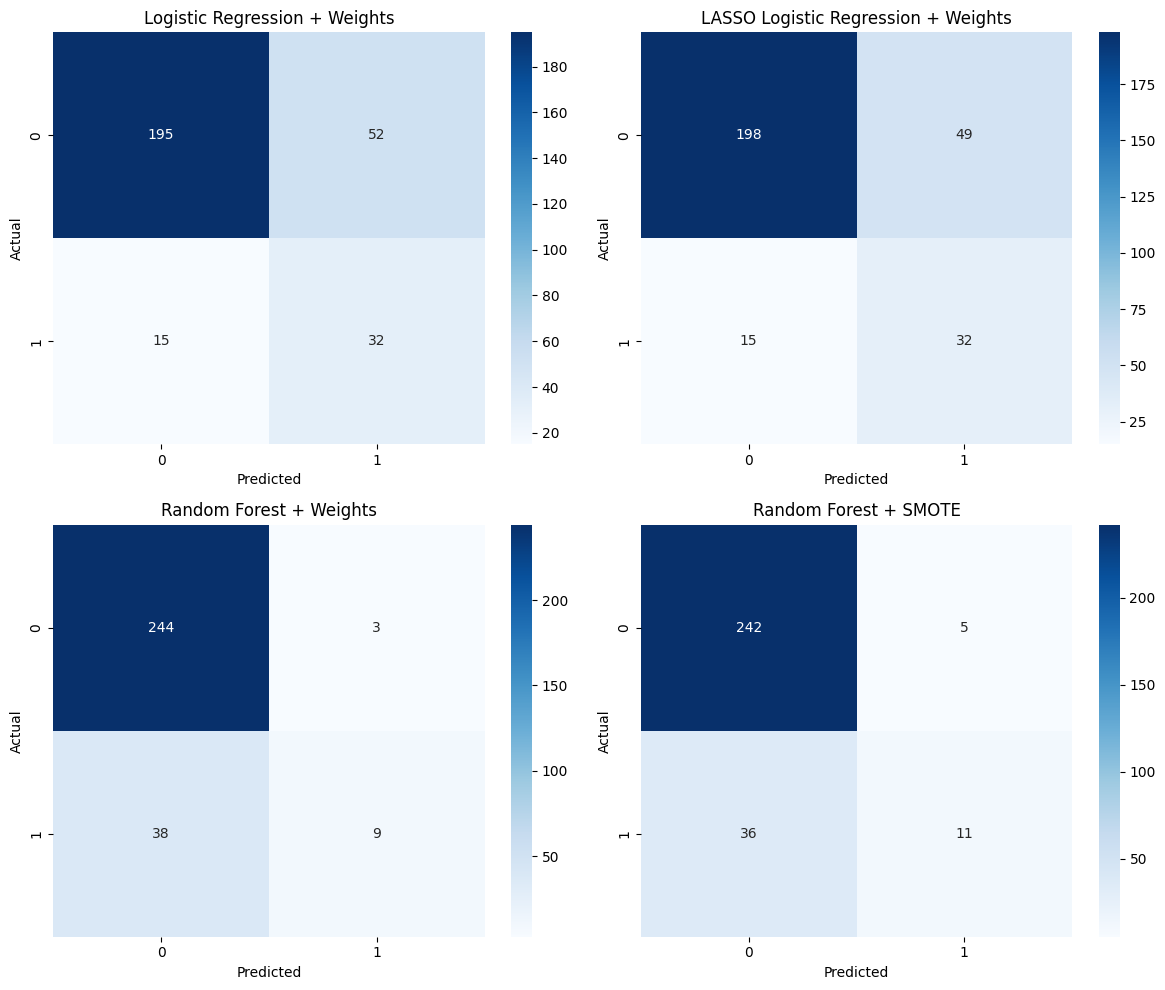

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

models = [
    ("Logistic Regression + Weights", log_reg, X_test_scaled),
    ("LASSO Logistic Regression + Weights", lasso, X_test_scaled),
    ("Random Forest + Weights", rf_weights, X_test),
    ("Random Forest + SMOTE", rf_smote, X_test)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model, X_eval) in zip(axes, models):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 3.4.2 Model Comparison Summary
Logistic Regression (weights): Best balance of recall and AUROC, effective at identifying attrition cases.

LASSO Logistic Regression (weights): Matches Logistic Regression performance, with slightly better precision and added benefit of feature selection.

Random Forest (weights): High accuracy but very poor recall, unsuitable for attrition prediction.

Random Forest (SMOTE): Recall improves modestly but remains weak compared to Logistic Regression.

**Conclusion**: Logistic Regression (both standard and LASSO) are the most effective for attrition prediction. Between the two, LASSO Logistic Regression with weights is preferable because it maintains recall, improves precision slightly, and provides feature selection for interpretability. Random Forest models, even with SMOTE, favor overall accuracy but fail to capture minority attrition cases.
